In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

path = "/common/home/lh811/Documents/cleaned.csv"

In [2]:
def load(path):
  # load csv into a pd dataframe; cast values to np.float32's for memory purposes; turn values in date to proper datetime objects; sort rows by permno, and inside permno groups, date
  df = pd.read_csv(path, dtype={col: np.float32 for col in pd.read_csv(path, nrows=0).columns if col not in ['DATE', 'year_month', 'permno']})
  df['DATE'] = pd.to_datetime(df['DATE'])
  df['year_month'] = pd.to_datetime(df['year_month']).dt.to_period('M')
  df = df.sort_values(['permno', 'DATE']).reset_index(drop=True)

  print(f"Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
  print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns")

  return df

clean = load(path)

Memory: 1.25 GB
Loaded 3016262 rows and 101 columns


In [3]:

def get_features_and_target(df, target_col='monthly_excess_ret'):
  drop_cols = ['DATE', 'year_month', 'permno', 'monthly_ret_raw', 'RF', target_col] # not included
  feature_cols = [c for c in df.columns if c not in drop_cols]
  temp_df = df.dropna(subset=feature_cols + [target_col])

  X = temp_df[feature_cols].values
  y = temp_df[target_col].values

  return X, y, temp_df


def split_paper(df, initial_train_years=18, 
                val_years=12, test_years=1, date_col="DATE"):
    
    df = df.sort_values(date_col).reset_index(drop=True)

    start_date = df[date_col].min()
    end_date   = df[date_col].max()

    train_end = start_date + pd.DateOffset(years=initial_train_years)

    while True:

        val_start = train_end
        val_end   = val_start + pd.DateOffset(years=val_years)

        test_start = val_end
        test_end   = test_start + pd.DateOffset(years=test_years)

        if test_end > end_date:
            break

        train_df = df[df[date_col] < train_end]

        val_df = df[
            (df[date_col] >= val_start) &
            (df[date_col] <  val_end)
        ]

        test_df = df[
            (df[date_col] >= test_start) &
            (df[date_col] <  test_end)
        ]

        print(
            f"Train: {train_df[date_col].min().date()} → "
            f"{train_df[date_col].max().date()} | "
            f"Val: {val_df[date_col].min().date()} → "
            f"{val_df[date_col].max().date()} | "
            f"Test: {test_df[date_col].min().date()} → "
            f"{test_df[date_col].max().date()}"
        )

        yield train_df, val_df, test_df

        # move forward ONE year only
        train_end = train_end + pd.DateOffset(years=1)

def r2(y_test, y_pred):
    num = np.sum((y_test - y_pred)**2)
    den = np.sum(y_test**2)
    r2 = 100*(1 - (num/den))
    return r2

In [4]:
nn_results = []
nn_predictions = []

nn_dict = {
  'nn1': [32],
  'nn2': [32, 16],
  'nn3': [32, 16, 8],
  'nn4': [32, 16, 8, 4],
  'nn5': [32, 16, 8, 4, 2]
}

l1_grid = np.logspace(-5, -3, 11)
lr_grid = [0.001, 0.01]

# paper designated parameters
epochs = 100
batch_size = 10000
patience = 5
ensemble_seeds = list(range(10))

def build_model(arch, input_dim):
    layers = []
    prev = input_dim

    for h in arch:
        layers.append(nn.Linear(prev, h))
        layers.append(nn.ReLU())
        layers.append(nn.BatchNorm1d(h))
        prev = h

    # Final regression layer mapping to continuous return prediction
    layers.append(nn.Linear(prev, 1))
    return nn.Sequential(*layers)


for train, val, test in split_paper(clean):

    X_train, y_train, _ = get_features_and_target(train)
    X_val, y_val, _ = get_features_and_target(val)
    X_test, y_test, test_df = get_features_and_target(test)

    X_train_t = torch.tensor(np.asarray(X_train), dtype=torch.float32)
    y_train_t = torch.tensor(np.asarray(y_train), dtype=torch.float32)
    X_val_t = torch.tensor(np.asarray(X_val), dtype=torch.float32)
    y_val_t = torch.tensor(np.asarray(y_val), dtype=torch.float32)
    X_test_t = torch.tensor(np.asarray(X_test), dtype=torch.float32)
    
    input_dim = X_train_t.shape[1]

    for name, arch in nn_dict.items():

        # =================================================================
        # tune the learning rate and l1 penalty
        # =================================================================
        best_overall_val_loss = float('inf')
        best_lr, best_l1 = None, None
        
        torch.manual_seed(13)
        np.random.seed(13)

        for l1 in l1_grid:
            for lr in lr_grid:
                
                model = build_model(arch, input_dim)
                opt = torch.optim.Adam(model.parameters(), lr=lr) # Default Adam configs
                mse_loss = nn.MSELoss()

                best_val_loss = float('inf')
                patience_count = 0

                for epoch in range(epochs):
                    model.train()
                    perm = torch.randperm(X_train_t.shape[0])
                    Xs = X_train_t[perm]
                    ys = y_train_t[perm]

                    for i in range(0, X_train_t.shape[0], batch_size):
                        xb = Xs[i:i+batch_size]
                        yb = ys[i:i+batch_size]

                        opt.zero_grad()
                        pred = model(xb).view(-1)
                        
                        mse = mse_loss(pred, yb)
                        l1_pen = sum(p.abs().sum() for p in model.parameters())

                        loss = mse + (l1 * l1_pen) 
                        
                        loss.backward()
                        opt.step()

                    # early stopping following paper method
                    model.eval()
                    with torch.no_grad():
                        val_pred = model(X_val_t).view(-1)
                        val_loss = mse_loss(val_pred, y_val_t).item()

                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        patience_count = 0
                    else:
                        patience_count += 1
                        if patience_count >= patience:
                            break

                # FIXED: Tracks the absolute lowest validation loss cleared during tuning
                if best_val_loss < best_overall_val_loss:
                    best_overall_val_loss = best_val_loss
                    best_lr = lr
                    best_l1 = l1

        # =================================================================
        # ensemble training (10 different seeds)
        # =================================================================
        seed_preds = []

        assert best_lr is not None
        assert best_l1 is not None 

        for seed in ensemble_seeds:
            torch.manual_seed(seed)
            np.random.seed(seed)

            model = build_model(arch, input_dim)
            opt = torch.optim.Adam(model.parameters(), lr=best_lr)
            mse_loss = nn.MSELoss()

            best_val_loss = float('inf')
            best_state = None
            patience_count = 0

            for epoch in range(epochs):
                model.train()
                perm = torch.randperm(X_train_t.shape[0])
                Xs = X_train_t[perm]
                ys = y_train_t[perm]

                for i in range(0, X_train_t.shape[0], batch_size):
                    xb = Xs[i:i+batch_size]
                    yb = ys[i:i+batch_size]

                    opt.zero_grad()
                    pred = model(xb).view(-1)
                    
                    mse = mse_loss(pred, yb)
                    l1_pen = sum(p.abs().sum() for p in model.parameters())
                    
                    loss = mse + (best_l1 * l1_pen) 
                    
                    loss.backward()
                    opt.step()

                # Validate for Early Stopping
                model.eval()
                with torch.no_grad():
                    val_pred = model(X_val_t).view(-1)
                    val_loss = mse_loss(val_pred, y_val_t).item()

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_state = {k: v.clone() for k, v in model.state_dict().items()}
                    patience_count = 0
                else:
                    patience_count += 1
                    if patience_count >= patience:
                        break

            # Load the optimal early-stopped weights for this specific seed
            final_seed_model = build_model(arch, input_dim)
            
            if best_state is None:
                best_state = model.state_dict()
            
            final_seed_model.load_state_dict(best_state)
            final_seed_model.eval()

            with torch.no_grad():
                test_pred = final_seed_model(X_test_t).view(-1).numpy()
            
            seed_preds.append(test_pred)

        # =================================================================
        # aggregation and model evaluation
        # =================================================================
        final_pred = np.mean(np.stack(seed_preds), axis=0)
        
        nn_predictions.append(pd.DataFrame({
            'permno': test_df['permno'].values,
            'DATE': test_df['DATE'].values,
            'true': y_test,
            'pred': final_pred,
            'model': name
        }))

        current_r2 = r2(y_test, final_pred)

        nn_results.append({
            'test_start': test['DATE'].min().date(),
            'test_end': test['DATE'].max().date(),
            'architecture': name,
            'test_r2': current_r2,
            'test_mse': mean_squared_error(y_test, final_pred)
        })

        print(
            f"{name} Completed: "
            f"best_lr={best_lr}, "
            f"best_l1={best_l1}, "
            f"OOS R2={current_r2:.4f}%"
        )

nn_predictions_df = pd.concat(nn_predictions, ignore_index=True)
nn_predictions_df.to_csv(
    '/common/home/lh811/Documents/ML_Pricing/data/aggregate_model_performance/nn_predictions.csv',
    index=False
)

Train: 1985-01-31 → 2002-12-31 | Val: 2003-01-31 → 2015-01-30 | Test: 2015-02-27 → 2016-01-29
nn1 Completed: best_lr=0.01, best_l1=0.0002511886431509582, OOS R2=-0.8097%
nn2 Completed: best_lr=0.01, best_l1=2.5118864315095822e-05, OOS R2=-0.7502%
nn3 Completed: best_lr=0.01, best_l1=0.001, OOS R2=-0.9946%
nn4 Completed: best_lr=0.01, best_l1=0.0002511886431509582, OOS R2=-0.5239%
nn5 Completed: best_lr=0.001, best_l1=0.000630957344480193, OOS R2=-0.9140%
Train: 1985-01-31 → 2004-01-30 | Val: 2004-02-27 → 2016-01-29 | Test: 2016-02-29 → 2016-12-30
nn1 Completed: best_lr=0.001, best_l1=0.000630957344480193, OOS R2=0.7520%
nn2 Completed: best_lr=0.01, best_l1=0.0001, OOS R2=0.5845%
nn3 Completed: best_lr=0.01, best_l1=0.00039810717055349735, OOS R2=0.9757%
nn4 Completed: best_lr=0.001, best_l1=0.001, OOS R2=1.1823%
nn5 Completed: best_lr=0.01, best_l1=3.9810717055349695e-05, OOS R2=1.1042%
Train: 1985-01-31 → 2004-12-31 | Val: 2005-01-31 → 2016-12-30 | Test: 2017-01-31 → 2017-12-29
nn1 Co

In [5]:
nn_performance = pd.DataFrame(nn_results)
nn_performance['test_start'] = pd.to_datetime(
    nn_performance['test_start']
)

nn_performance.to_csv("/common/home/lh811/Documents/ML_Pricing/data/individual_model_performance/nn_models.csv", index = False)

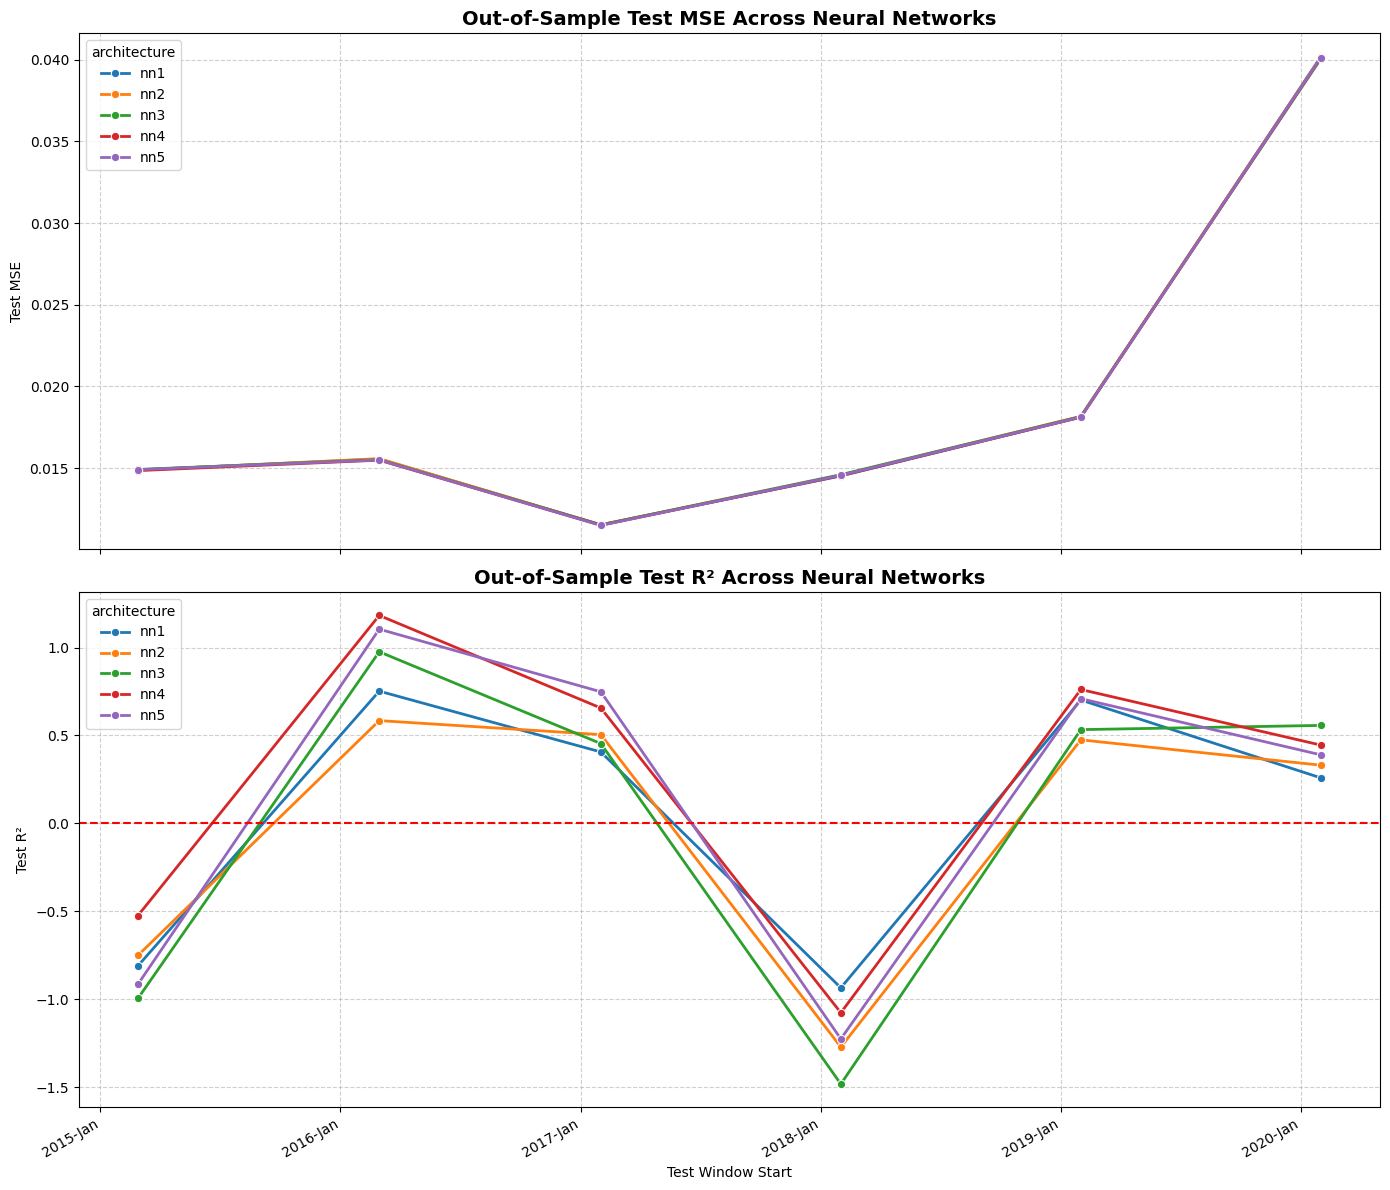

In [6]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 12),
    sharex=True
)

# ---------------------------------------------------
# TEST MSE
# ---------------------------------------------------

sns.lineplot(
    data=nn_performance,
    x='test_start',
    y='test_mse',
    hue='architecture',
    marker='o',
    linewidth=2,
    ax=axes[0]
)

axes[0].set_title(
    'Out-of-Sample Test MSE Across Neural Networks',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_ylabel('Test MSE')

axes[0].grid(True, linestyle='--', alpha=0.6)

# ---------------------------------------------------
# TEST R²
# ---------------------------------------------------

sns.lineplot(
    data=nn_performance,
    x='test_start',
    y='test_r2',
    hue='architecture',
    marker='o',
    linewidth=2,
    ax=axes[1]
)

axes[1].set_title(
    'Out-of-Sample Test R² Across Neural Networks',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Test Window Start')

axes[1].set_ylabel('Test R²')

axes[1].axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=1.5
)

axes[1].grid(True, linestyle='--', alpha=0.6)

axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%b')
)

fig.autofmt_xdate()

plt.tight_layout()

plt.show()